In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Configurações
MODEL_NAME = "melll-uff/bertweetbr"  # Ajuste se precisar de mais memória
LR_MODEL_PATH = "C:\\Users\\Mateus Monteleone\\Projects\\ic\\logreg_400_tweets.pkl"

c:\Users\Mateus Monteleone\Projects\ic\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet("C:\\Users\\Mateus Monteleone\\Projects\\ic\\data\\tweets_base_normalizados.parquet")

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()
print("BERTweetBR carregado com sucesso.")

Some weights of RobertaModel were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTweetBR carregado com sucesso.


In [4]:
clf = joblib.load(LR_MODEL_PATH)
print("Logistic Regression carregado com sucesso.")

Logistic Regression carregado com sucesso.


In [5]:
def predict_sentiment_streaming(
    df,
    text_col,
    tokenizer,
    model,
    clf,
    batch_size=512,
    max_length=128
):
    sentiments = []

    for i in range(0, len(df), batch_size):
        batch_texts = df[text_col].iloc[i:i+batch_size].tolist()

        with torch.no_grad():
            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_length
            )
            outputs = model(**inputs)
            cls_embeds = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        batch_preds = clf.predict(cls_embeds)
        sentiments.extend(batch_preds)

        # limpeza explícita
        del inputs, outputs, cls_embeds
        torch.cuda.empty_cache()

        if i % (batch_size * 10) == 0:
            print(f"Processado {i} / {len(df)} tweets")

    return sentiments

In [6]:
df["unsupervised_sentiment"] = predict_sentiment_streaming(
    df=df,
    text_col="clean_text",
    tokenizer=tokenizer,
    model=model,
    clf=clf,
    batch_size=256  # recomendo 256 ou 128 no CPU
)

Processado 0 / 192954 tweets
Processado 2560 / 192954 tweets
Processado 5120 / 192954 tweets
Processado 7680 / 192954 tweets
Processado 10240 / 192954 tweets
Processado 12800 / 192954 tweets
Processado 15360 / 192954 tweets
Processado 17920 / 192954 tweets
Processado 20480 / 192954 tweets
Processado 23040 / 192954 tweets
Processado 25600 / 192954 tweets
Processado 28160 / 192954 tweets
Processado 30720 / 192954 tweets
Processado 33280 / 192954 tweets
Processado 35840 / 192954 tweets
Processado 38400 / 192954 tweets
Processado 40960 / 192954 tweets
Processado 43520 / 192954 tweets
Processado 46080 / 192954 tweets
Processado 48640 / 192954 tweets
Processado 51200 / 192954 tweets
Processado 53760 / 192954 tweets
Processado 56320 / 192954 tweets
Processado 58880 / 192954 tweets
Processado 61440 / 192954 tweets
Processado 64000 / 192954 tweets
Processado 66560 / 192954 tweets
Processado 69120 / 192954 tweets
Processado 71680 / 192954 tweets
Processado 74240 / 192954 tweets
Processado 76800 

Frequência de cada rótulo do modelo:
unsupervised_sentiment
-1.0    69544
 0.0    53624
 1.0    69786
Name: count, dtype: int64

Medidas descritivas:
count    192954.000000
mean          0.001254
std           0.849760
min          -1.000000
25%          -1.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: unsupervised_sentiment, dtype: float64


C:\Users\Mateus Monteleone\AppData\Local\Temp\ipykernel_9364\2024392765.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


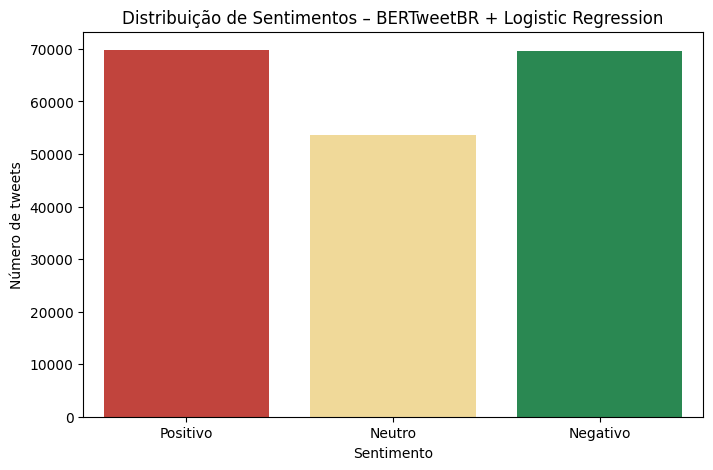

In [7]:
print("Frequência de cada rótulo do modelo:")
print(df["unsupervised_sentiment"].value_counts().sort_index())

print("\nMedidas descritivas:")
print(df["unsupervised_sentiment"].describe())

# Histograma
plt.figure(figsize=(8,5))
sns.countplot(
    x=df["unsupervised_sentiment"].map({-1:"Negativo", 0:"Neutro", 1:"Positivo"}),
    palette=["#d73027", "#fee08b", "#1a9850"]
)
plt.title("Distribuição de Sentimentos – BERTweetBR + Logistic Regression")
plt.xlabel("Sentimento")
plt.ylabel("Número de tweets")
plt.show()


In [8]:
df.to_parquet("C:\\Users\\Mateus Monteleone\\Projects\\ic\\data\\tweets_192k_labeled.parquet", index=False)
print("Arquivo salvo: tweets_192k_labeled.parquet")

Arquivo salvo: tweets_192k_labeled.parquet
